In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
import subprocess
warnings.filterwarnings('ignore')

import nltk
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('punkt_tab')

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import SnowballStemmer

print("✅ Bibliothèques NLP importées")

✅ Bibliothèques NLP importées


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\rabeb\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\rabeb\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\rabeb\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\rabeb\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [2]:
df = pd.read_csv('../data/processed/dataset_clean.csv')
df_nlp = df[df['Categorie'].notna()].copy()

print(f"Shape : {df_nlp.shape}")
print(f"\nExemples de textes :")
for i in range(3):
    print(f"\n→ Categorie : {df_nlp['Categorie'].iloc[i]}")
    print(f"  Texte : {df_nlp['Rapport_Collecte'].iloc[i][:100]}...")

Shape : (7123, 11)

Exemples de textes :

→ Categorie : Papier
  Texte : Lot de papier récupéré dans un site non renseigné. Poids léger de 16.7 kg, volume moyen. Matériau so...

→ Categorie : Plastique
  Texte : Lot plastique à l'Usine A. Volume 64.7 L, poids 47.3 kg. Aspect indéterminée, rigidité moyenne. Aucu...

→ Categorie : Plastique
  Texte : Déchet plastique collecté à l'Usine B. Poids 33.0 kg, volume 44.0 L. Rigidité semi-rigide, non condu...


In [3]:
def nettoyer_texte(texte):
    # 1. Minuscules
    texte = texte.lower()
    # 2. Supprimer chiffres et ponctuation
    texte = re.sub(r'[^a-zàâäéèêëîïôùûüç\s]', ' ', texte)
    # 3. Supprimer espaces multiples
    texte = re.sub(r'\s+', ' ', texte).strip()
    return texte

# Tester
exemple = df_nlp['Rapport_Collecte'].iloc[0]
print("AVANT :", exemple[:100])
print("APRES :", nettoyer_texte(exemple)[:100])

AVANT : Lot de papier récupéré dans un site non renseigné. Poids léger de 16.7 kg, volume moyen. Matériau so
APRES : lot de papier récupéré dans un site non renseigné poids léger de kg volume moyen matériau souple non


In [4]:
# Stopwords français + domaine
stop_fr = set(stopwords.words('french'))
stop_domaine = {
    # Termes génériques du domaine
    'lot', 'déchet', 'collecté', 'volume', 'poids',
    'kg', 'litre', 'usine', 'site', 'matériau', 'aspect',
    # Noms des catégories — cause du data leakage
    'papier', 'plastique', 'metal', 'métal', 'verre',
    'organique', 'carton', 'aluminium', 'ferreux', 'ferraille'
}
tous_stopwords = stop_fr.union(stop_domaine)

# Stemmer français
stemmer = SnowballStemmer('french')

def pretraiter_texte(texte):
    # 1. Nettoyage
    texte = nettoyer_texte(texte)
    # 2. Tokenisation
    tokens = word_tokenize(texte, language='french')
    # 3. Suppression stopwords
    tokens = [t for t in tokens if t not in tous_stopwords]
    # 4. Stemming
    tokens = [stemmer.stem(t) for t in tokens]
    return ' '.join(tokens)

# Appliquer sur tout le dataset
df_nlp['texte_propre'] = df_nlp['Rapport_Collecte'].apply(pretraiter_texte)

print(" Prétraitement terminé !")
print("\nAvant :", df_nlp['Rapport_Collecte'].iloc[0][:80])
print("Après :", df_nlp['texte_propre'].iloc[0][:80])

 Prétraitement terminé !

Avant : Lot de papier récupéré dans un site non renseigné. Poids léger de 16.7 kg, volum
Après : récuper non renseign leg moyen soupl non conducteur tres opaqu bon état général


In [5]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split

# Cible
y = df_nlp['Categorie']
X_text = df_nlp['texte_propre']

# Split
X_train, X_temp, y_train, y_temp = train_test_split(
    X_text, y, test_size=0.30, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

# Bag of Words
bow = CountVectorizer()
X_train_bow = bow.fit_transform(X_train)
X_test_bow = bow.transform(X_test)

# TF-IDF
tfidf = TfidfVectorizer(ngram_range=(1,2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf = tfidf.transform(X_val)
X_test_tfidf = tfidf.transform(X_test)

print(f" Vectorisation terminée")
print(f"BOW shape   : {X_train_bow.shape}")
print(f"TF-IDF shape: {X_train_tfidf.shape}")

 Vectorisation terminée
BOW shape   : (4986, 110)
TF-IDF shape: (4986, 596)


In [6]:
# === BOW + TF-IDF — scores stockés dans dict ===
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score

scores = {}  # ← dict global pour stocker tous les scores

classificateurs = {
    'Naive Bayes'        : MultinomialNB(),
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'LinearSVC'          : LinearSVC(),
    'Random Forest'      : RandomForestClassifier(n_estimators=100, random_state=42)
}

print("=== BOW ===")
for nom, clf in classificateurs.items():
    clf.fit(X_train_bow, y_train)
    y_pred = clf.predict(X_test_bow)
    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred, average='weighted')
    scores[f'BoW + {nom}'] = acc      # ← sauvegarde score
    print(f"{nom:25s} → Accuracy: {acc:.4f} | F1: {f1:.4f}")

classificateurs2 = {
    'Naive Bayes'        : MultinomialNB(),
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'LinearSVC'          : LinearSVC(),
    'Random Forest'      : RandomForestClassifier(n_estimators=100, random_state=42)
}

print("\n=== TF-IDF ===")
for nom, clf in classificateurs2.items():
    clf.fit(X_train_tfidf, y_train)
    y_pred = clf.predict(X_test_tfidf)
    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred, average='weighted')
    scores[f'TF-IDF + {nom}'] = acc   # ← sauvegarde score
    print(f"{nom:25s} → Accuracy: {acc:.4f} | F1: {f1:.4f}")

=== BOW ===
Naive Bayes               → Accuracy: 0.9963 | F1: 0.9963
Logistic Regression       → Accuracy: 1.0000 | F1: 1.0000
LinearSVC                 → Accuracy: 1.0000 | F1: 1.0000
Random Forest             → Accuracy: 1.0000 | F1: 1.0000

=== TF-IDF ===
Naive Bayes               → Accuracy: 1.0000 | F1: 1.0000
Logistic Regression       → Accuracy: 1.0000 | F1: 1.0000
LinearSVC                 → Accuracy: 1.0000 | F1: 1.0000
Random Forest             → Accuracy: 1.0000 | F1: 1.0000


In [7]:
# Word2Vec non disponible pour Python 3.14
# On utilise TF-IDF avec SVD comme alternative (LSA)
from sklearn.decomposition import TruncatedSVD
from sklearn.pipeline import Pipeline

# LSA = TF-IDF + réduction dimensionnelle (équivalent sémantique)
lsa_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1,2))),
    ('svd', TruncatedSVD(n_components=100, random_state=42))
])

X_train_lsa = lsa_pipeline.fit_transform(X_train)
X_test_lsa = lsa_pipeline.transform(X_test)

print(f" LSA (alternative Word2Vec) shape: {X_train_lsa.shape}")

 LSA (alternative Word2Vec) shape: (4986, 100)


In [8]:
# === LSA — scores stockés ===
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

print("=== LSA (alternative Word2Vec) ===")
for nom, clf in {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'LinearSVC':           LinearSVC()
}.items():
    clf.fit(X_train_lsa, y_train)
    y_pred = clf.predict(X_test_lsa)
    acc = accuracy_score(y_test, y_pred)
    scores[f'LSA + {nom}'] = acc      # ← sauvegarde score
    print(f"{nom:25s} → Accuracy: {acc:.4f}")

=== LSA (alternative Word2Vec) ===
Logistic Regression       → Accuracy: 1.0000
LinearSVC                 → Accuracy: 1.0000


In [9]:
# === FastText-like — score stocké ===
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score

fasttext_like = TfidfVectorizer(
    analyzer='char_wb',
    ngram_range=(3, 5),
    min_df=2
)

X_train_ft = fasttext_like.fit_transform(X_train)
X_test_ft  = fasttext_like.transform(X_test)

clf_ft = LinearSVC()
clf_ft.fit(X_train_ft, y_train)
y_pred_ft = clf_ft.predict(X_test_ft)

acc_ft = accuracy_score(y_test, y_pred_ft)
scores['FastText-like + LinearSVC'] = acc_ft  # ← sauvegarde score
print(f" FastText-like (char n-grammes) → Accuracy: {acc_ft:.4f}")
print(f"   Avantage : robuste aux fautes d'orthographe")

 FastText-like (char n-grammes) → Accuracy: 1.0000
   Avantage : robuste aux fautes d'orthographe


In [12]:
subprocess.run(['pip', 'install', 'sentence-transformers'], check=True)

CompletedProcess(args=['pip', 'install', 'sentence-transformers'], returncode=0)

In [13]:
from sentence_transformers import SentenceTransformer
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score

print(" Chargement CamemBERT (première fois = téléchargement ~500MB)...")

# Charger le modèle CamemBERT
model_bert = SentenceTransformer('camembert-base')

print(" CamemBERT chargé !")

# Vectoriser les textes
print(" Vectorisation en cours...")
X_train_bert = model_bert.encode(X_train.tolist(), show_progress_bar=True)
X_test_bert = model_bert.encode(X_test.tolist(), show_progress_bar=True)

print(f" BERT shape: {X_train_bert.shape}")

 Chargement CamemBERT (première fois = téléchargement ~500MB)...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 1893.63it/s]
[transformers] CamembertModel LOAD REPORT from: camembert-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


 CamemBERT chargé !
 Vectorisation en cours...


Batches: 100%|██████████| 34/34 [00:40<00:00,  1.21s/it]

 BERT shape: (4986, 768)


=== COMPARAISON FINALE TOUTES APPROCHES NLP ===
                              Accuracy
BoW + Logistic Regression       1.0000
BoW + LinearSVC                 1.0000
BoW + Random Forest             1.0000
TF-IDF + Random Forest          1.0000
TF-IDF + Naive Bayes            1.0000
TF-IDF + Logistic Regression    1.0000
TF-IDF + LinearSVC              1.0000
LSA + LinearSVC                 1.0000
LSA + Logistic Regression       1.0000
FastText-like + LinearSVC       1.0000
BoW + Naive Bayes               0.9963


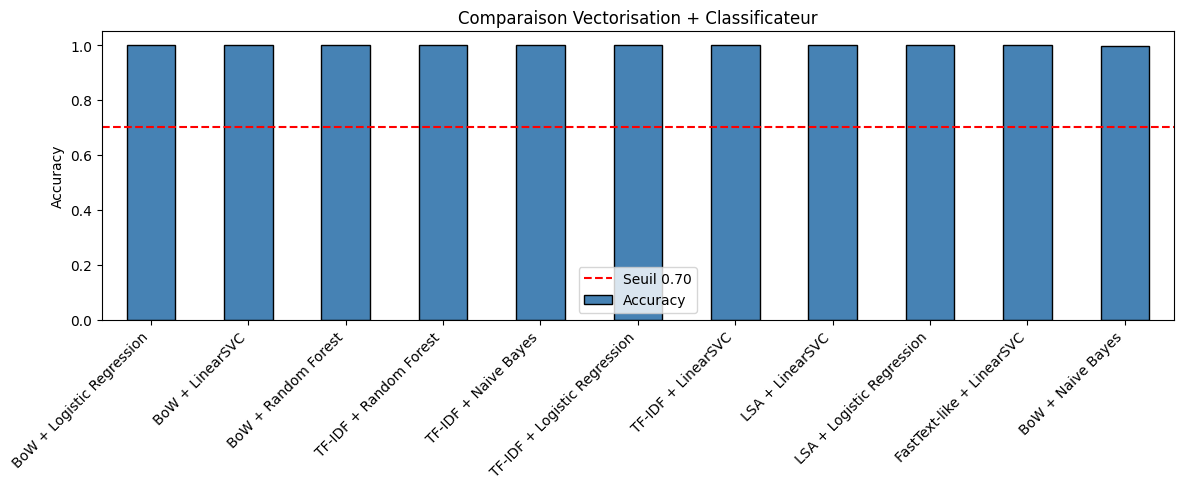


 Meilleure combinaison : BoW + Logistic Regression (1.0000)


In [14]:
# === TABLEAU COMPARATIF FINAL ===
df_comparaison = pd.DataFrame({
    'Accuracy': scores
}).sort_values('Accuracy', ascending=False)

print("=== COMPARAISON FINALE TOUTES APPROCHES NLP ===")
print(df_comparaison.round(4))

plt.figure(figsize=(12, 5))
df_comparaison['Accuracy'].plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Comparaison Vectorisation + Classificateur')
plt.ylabel('Accuracy')
plt.xticks(rotation=45, ha='right')
plt.axhline(y=0.70, color='red', linestyle='--', label='Seuil 0.70')
plt.legend()
plt.tight_layout()
plt.show()

meilleur_nlp = max(scores, key=scores.get)
print(f"\n Meilleure combinaison : {meilleur_nlp} ({scores[meilleur_nlp]:.4f})")

In [15]:
# === SAUVEGARDE ===
import joblib, os

os.makedirs('../models', exist_ok=True)

joblib.dump(tfidf,                         '../models/tfidf_vectorizer.pkl')
joblib.dump(classificateurs2['LinearSVC'], '../models/nlp_classifier.pkl')

meilleur_nlp = max(scores, key=scores.get)
print(f" Meilleure combinaison : {meilleur_nlp} ({scores[meilleur_nlp]:.4f})")
print(" TF-IDF vectorizer → models/tfidf_vectorizer.pkl")
print(" NLP classifier    → models/nlp_classifier.pkl")

 Meilleure combinaison : BoW + Logistic Regression (1.0000)
 TF-IDF vectorizer → models/tfidf_vectorizer.pkl
 NLP classifier    → models/nlp_classifier.pkl


In [16]:
# ============================================================
# MODULE 5 — PIPELINE MULTIMODAL
# Fusion features numériques + textuelles
# ============================================================

from scipy.sparse import hstack, csr_matrix
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [17]:
features_num = ['Poids', 'Volume', 'Conductivite', 'Opacite', 'Rigidite', 'Source_encoded']

# Récupérer les features numériques avec les mêmes indices que le split NLP
df_mm = df[df['Categorie'].notna()].copy()

X_num_train = df_mm.loc[X_train.index, features_num]
X_num_val   = df_mm.loc[X_val.index,   features_num]
X_num_test  = df_mm.loc[X_test.index,  features_num]

print(f"Numérique train : {X_num_train.shape}")
print(f"Numérique val   : {X_num_val.shape}")

Numérique train : (4986, 6)
Numérique val   : (1068, 6)


In [18]:
scaler_mm = StandardScaler()
X_scaled_train = scaler_mm.fit_transform(X_num_train)
X_scaled_val   = scaler_mm.transform(X_num_val)
X_scaled_test  = scaler_mm.transform(X_num_test)

# Fusion sparse : TF-IDF (déjà calculé) + Numérique
X_fusion_train = hstack([X_train_tfidf, csr_matrix(X_scaled_train)])
X_fusion_val   = hstack([X_val_tfidf,   csr_matrix(X_scaled_val)])
X_fusion_test  = hstack([X_test_tfidf,  csr_matrix(X_scaled_test)])

print(f" Fusion shape : {X_fusion_train.shape}")
print(f"   = {X_train_tfidf.shape[1]} TF-IDF + {X_scaled_train.shape[1]} numérique")

 Fusion shape : (4986, 602)
   = 596 TF-IDF + 6 numérique


In [19]:
from sklearn.ensemble import GradientBoostingClassifier

modeles_mm = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'LinearSVC':           LinearSVC(),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting':   GradientBoostingClassifier(random_state=42)
}

scores_mm = {}
print("=== MODELES SUR FUSION (NLP + Numérique) ===")
for nom, modele in modeles_mm.items():
    modele.fit(X_fusion_train, y_train)
    y_pred = modele.predict(X_fusion_val)
    acc = accuracy_score(y_val, y_pred)
    f1  = f1_score(y_val, y_pred, average='weighted')
    scores_mm[nom] = acc
    print(f"{nom:25s} → Accuracy: {acc:.4f} | F1: {f1:.4f}")

=== MODELES SUR FUSION (NLP + Numérique) ===
Logistic Regression       → Accuracy: 1.0000 | F1: 1.0000
LinearSVC                 → Accuracy: 1.0000 | F1: 1.0000
Random Forest             → Accuracy: 1.0000 | F1: 1.0000
Gradient Boosting         → Accuracy: 1.0000 | F1: 1.0000


                       Pipeline  Accuracy
0                      NLP seul    1.0000
1                Numérique seul    0.9476
2  Fusion (Logistic Regression)    1.0000


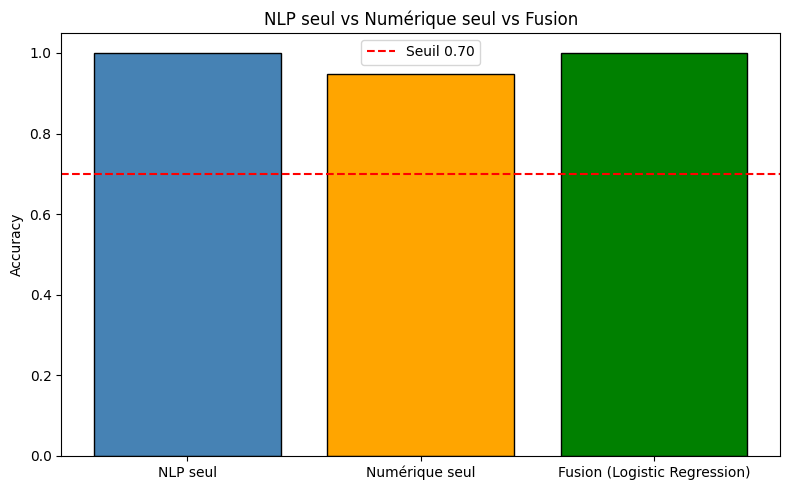


→ Gain fusion vs NLP seul       : +0.00%
→ Gain fusion vs Numérique seul  : +5.24%


In [20]:
# NLP seul — déjà calculé plus haut
acc_nlp = scores[max(scores, key=scores.get)]

# Numérique seul
clf_num = LinearSVC()
clf_num.fit(X_scaled_train, y_train)
acc_num = accuracy_score(y_val, clf_num.predict(X_scaled_val))

# Fusion
meilleur_nom_mm = max(scores_mm, key=scores_mm.get)
acc_fusion = scores_mm[meilleur_nom_mm]

comparaison = pd.DataFrame({
    'Pipeline': ['NLP seul', 'Numérique seul', f'Fusion ({meilleur_nom_mm})'],
    'Accuracy': [acc_nlp,    acc_num,           acc_fusion]
})
print(comparaison.round(4))

plt.figure(figsize=(8, 5))
plt.bar(comparaison['Pipeline'], comparaison['Accuracy'],
        color=['steelblue', 'orange', 'green'], edgecolor='black')
plt.axhline(y=0.70, color='red', linestyle='--', label='Seuil 0.70')
plt.title('NLP seul vs Numérique seul vs Fusion')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

print(f"\n→ Gain fusion vs NLP seul       : +{(acc_fusion-acc_nlp)*100:.2f}%")
print(f"→ Gain fusion vs Numérique seul  : +{(acc_fusion-acc_num)*100:.2f}%")

In [21]:
import joblib, os

os.makedirs('../models', exist_ok=True)

meilleur_modele_mm = modeles_mm[meilleur_nom_mm]

joblib.dump(tfidf,              '../models/tfidf_multimodal.pkl')
joblib.dump(scaler_mm,          '../models/scaler_multimodal.pkl')
joblib.dump(meilleur_modele_mm, '../models/classifier_multimodal.pkl')

print(" Modèle multimodal sauvegardé !")
print(f"   → classifier_multimodal.pkl  ({meilleur_nom_mm})")
print(f"   → tfidf_multimodal.pkl")
print(f"   → scaler_multimodal.pkl")

 Modèle multimodal sauvegardé !
   → classifier_multimodal.pkl  (Logistic Regression)
   → tfidf_multimodal.pkl
   → scaler_multimodal.pkl
